# US Accidents Exploratory Data Analysis

## Project Overview
This project performs exploratory data analysis (EDA) on the US Accidents dataset to understand patterns in traffic accidents across the United States.

Main objectives:

- Analyze accident distribution across cities and states
- Study time-based accident patterns
- Investigate the impact of weather and visibility
- Identify high-risk locations and time periods



## Introduction

Traffic accidents are a major public safety concern in the United States. Analyzing historical accident data can help identify patterns related to time, location, weather conditions, and accident severity.

This project explores the US Accidents dataset (2016–2023) to uncover trends and insights that may help understand accident risk factors.




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## Load the Dataset

In [3]:

df = pd.read_csv("../data/US_Accidents_March23.csv")

## Data Preparation and Cleaning

In this section we:

- explore the dataset structure
- inspect column information
- check missing values
- clean and prepare the data for analysis

### Dataset overview

In [4]:
df.head(5)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [5]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [6]:
df.shape

(7728394, 46)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [8]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [9]:

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

newdf = df.select_dtypes(include=numerics)
len(newdf.columns)


13

### Percentage of Missing Values per Column

In [10]:
missing_percent=df.isnull().sum().sort_values(ascending=False)/len(df)
missing_percent

End_Lng                  4.402935e-01
End_Lat                  4.402935e-01
Precipitation(in)        2.851286e-01
Wind_Chill(F)            2.586590e-01
Wind_Speed(mph)          7.391355e-02
Visibility(mi)           2.291524e-02
Wind_Direction           2.267043e-02
Humidity(%)              2.253301e-02
Weather_Condition        2.244438e-02
Temperature(F)           2.120143e-02
Pressure(in)             1.820288e-02
Weather_Timestamp        1.555666e-02
Sunrise_Sunset           3.007869e-03
Civil_Twilight           3.007869e-03
Astronomical_Twilight    3.007869e-03
Nautical_Twilight        3.007869e-03
Airport_Code             2.928810e-03
Street                   1.406372e-03
Timezone                 1.010300e-03
Zipcode                  2.477876e-04
City                     3.273643e-05
Description              6.469649e-07
ID                       0.000000e+00
Distance(mi)             0.000000e+00
Start_Lng                0.000000e+00
Source                   0.000000e+00
Severity    

In [11]:
missing_percent = missing_percent[missing_percent > 0]
missing_percent

End_Lng                  4.402935e-01
End_Lat                  4.402935e-01
Precipitation(in)        2.851286e-01
Wind_Chill(F)            2.586590e-01
Wind_Speed(mph)          7.391355e-02
Visibility(mi)           2.291524e-02
Wind_Direction           2.267043e-02
Humidity(%)              2.253301e-02
Weather_Condition        2.244438e-02
Temperature(F)           2.120143e-02
Pressure(in)             1.820288e-02
Weather_Timestamp        1.555666e-02
Sunrise_Sunset           3.007869e-03
Civil_Twilight           3.007869e-03
Astronomical_Twilight    3.007869e-03
Nautical_Twilight        3.007869e-03
Airport_Code             2.928810e-03
Street                   1.406372e-03
Timezone                 1.010300e-03
Zipcode                  2.477876e-04
City                     3.273643e-05
Description              6.469649e-07
dtype: float64

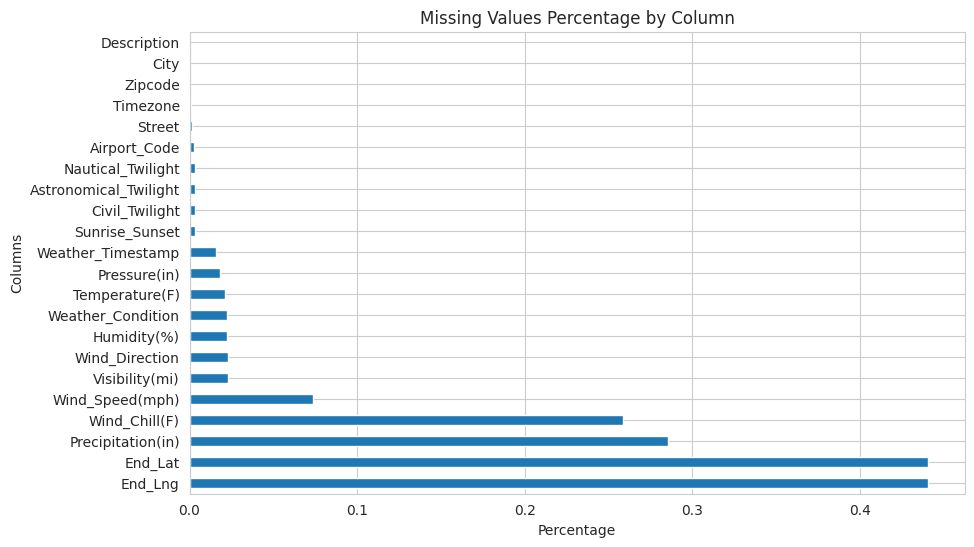

In [12]:
missing_percent.plot(kind='barh', figsize=(10,6))

plt.title("Missing Values Percentage by Column")
plt.xlabel("Percentage")
plt.ylabel("Columns")

plt.show()

### Missing Values Observation

Columns with extremely high missing percentages may not be useful for analysis and may be removed from the dataset.

remove the columns that more than half null values.

In [13]:
df.drop(['End_Lng', 'End_Lat'], axis=1, inplace=True)


Duplicate records can distort analysis, so we check if any rows are repeated.

In [14]:
df.duplicated().sum()

np.int64(0)

Missing values in **Precipitation(in)** are filled with `0.0`, assuming no precipitation was recorded.

In [15]:
# Filling the null values with 0.0
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)

In [16]:
df['Precipitation(in)'].isnull().sum()

np.int64(0)

Missing values in **Temperature(F)** are filled using the **median** to reduce the impact of extreme values or outliers.

In [17]:
# Filling the null values median
df['Temperature(F)']=df['Temperature(F)'].fillna(df['Temperature(F)'].median())

In [18]:
df['Temperature(F)'].isnull().sum()

np.int64(0)

Missing values in **Wind_Chill(F)** are replaced with **Temperature(F)** since wind chill is closely related to temperature.

In [19]:
#Fill missing values using Temperature
df['Wind_Chill(F)'] = df['Wind_Chill(F)'].fillna(df['Temperature(F)'])


In [20]:

df['Wind_Chill(F)'].isnull().sum()

np.int64(0)

### Handling Missing Numeric Values

Numeric columns such as humidity,Wind_Speed,Pressure are filled using the **median** value because it is less sensitive to extreme values.

In [21]:
# Filling the null values median(7)
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(7)
df['Wind_Speed(mph)'].isnull().sum()


np.int64(0)

In [22]:
# Fill Humidity with median
df['Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].median())

# Fill Pressure with median
df['Pressure(in)'] = df['Pressure(in)'].fillna(df['Pressure(in)'].median())




In [23]:
df['Humidity(%)'].isnull().sum()

np.int64(0)

In [24]:
df['Pressure(in)'].isnull().sum()

np.int64(0)

Categorical columns are filled using the **most frequent value (mode)**.

In [25]:
# Fill Weather_Condition with mode
df['Weather_Condition'] = df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0])

# Fill City with mode
df['City'] = df['City'].fillna(df['City'].mode()[0])

# Fill Timezone with mode
df['Timezone'] = df['Timezone'].fillna(df['Timezone'].mode()[0])


### Again checking percentage of Missing Values per Column

In [26]:
percentage=df.isnull().sum().sort_values(ascending=False)/len(df)
percentage

Visibility(mi)           2.291524e-02
Wind_Direction           2.267043e-02
Weather_Timestamp        1.555666e-02
Sunrise_Sunset           3.007869e-03
Nautical_Twilight        3.007869e-03
Civil_Twilight           3.007869e-03
Astronomical_Twilight    3.007869e-03
Airport_Code             2.928810e-03
Street                   1.406372e-03
Zipcode                  2.477876e-04
Description              6.469649e-07
ID                       0.000000e+00
County                   0.000000e+00
City                     0.000000e+00
Start_Lng                0.000000e+00
Distance(mi)             0.000000e+00
Start_Lat                0.000000e+00
End_Time                 0.000000e+00
Severity                 0.000000e+00
Start_Time               0.000000e+00
Source                   0.000000e+00
Temperature(F)           0.000000e+00
Pressure(in)             0.000000e+00
Humidity(%)              0.000000e+00
Wind_Chill(F)            0.000000e+00
Country                  0.000000e+00
Timezone    

## Exploratory data analysis and visualization

### geographical accident distribution:

#### Accident Distribution by State

In [27]:
#Accident Count per State
accident_per_state=df['State'].value_counts().reset_index()
accident_per_state.columns = ['State', 'Accident_Count']
top_accident_per_state=accident_per_state.head(10)
top_accident_per_state

,State,Accident_Count
0,CA,1741433
1,FL,880192
2,TX,582837
3,SC,382557
4,NY,347960
5,NC,338199
6,VA,303301
7,PA,296620
8,MN,192084
9,OR,179660


In [28]:
state_map_df = top_accident_per_state[['State', 'Accident_Count']].copy()
import plotly.express as px

fig = px.choropleth(
    state_map_df,
    locations='State',
    locationmode='USA-states',
    color='Accident_Count',
    hover_name='State',
    color_continuous_scale='Reds',
    scope='usa'
)

fig.update_layout(title_text='Accident Count by State')
fig.show()

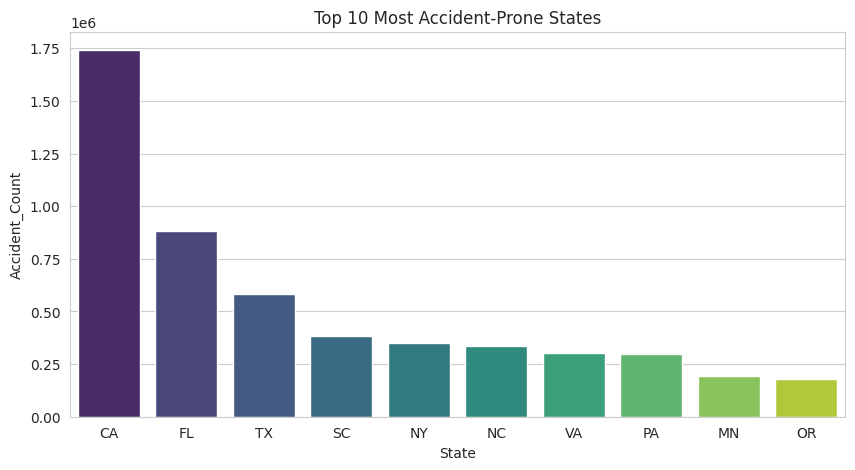

In [29]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_accident_per_state, x='State', y='Accident_Count',hue='State', palette='viridis')
plt.title("Top 10 Most Accident-Prone States")

plt.show()

In [30]:
unique_cities=df.City.unique()
len(unique_cities)

13678

#### Top 10 Cities with Highest Number of Accidents

In [31]:
# Cities with the top number of accidents
accidents_per_city = df['City'].value_counts().reset_index()

top_10_cities = accidents_per_city.head(10)
top_10_cities

,City,count
0,Miami,187170
1,Houston,169609
2,Los Angeles,156491
3,Charlotte,138652
4,Dallas,130939
5,Orlando,109733
6,Austin,97359
7,Raleigh,86079
8,Nashville,72930
9,Baton Rouge,71588


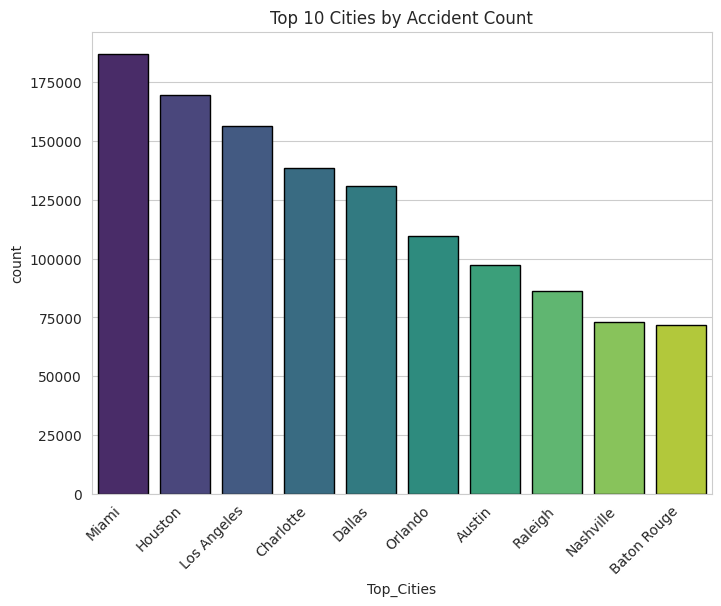

In [32]:
plt.figure(figsize=(8,6))
sns.barplot(data=top_10_cities,x='City',y='count',hue='City',palette='viridis',edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Top_Cities")
plt.ylabel('count')
plt.title('Top 10 Cities by Accident Count')
plt.show()


The bar chart shows the top 10 cities with the highest number of reported accidents in the dataset. Miami has the highest accident count, followed by Houston and Los Angeles. These cities may have higher traffic volume, larger populations, or more complex road networks, which contribute to more accident occurrences.

#### Distribution of Accident Counts Across Cities

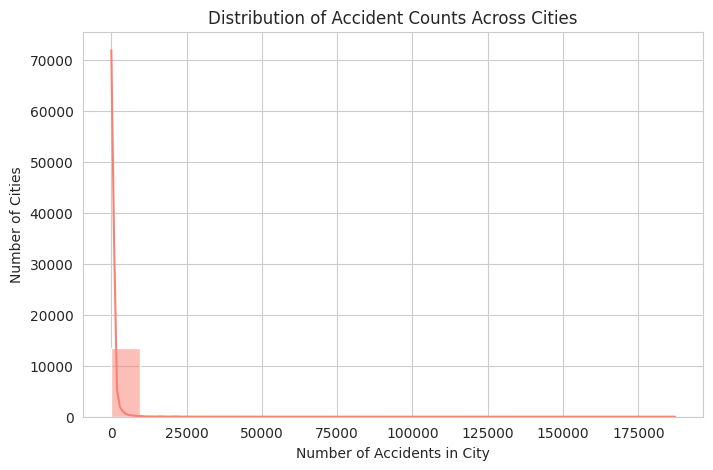

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(accidents_per_city['count'], bins=20, kde=True, color='salmon')
plt.title("Distribution of Accident Counts Across Cities")
plt.xlabel("Number of Accidents in City")
plt.ylabel("Number of Cities")
plt.show()

The distribution of accident counts across cities is highly right-skewed. This indicates that a small number of cities experience a very high number of accidents, while most cities have relatively few accidents.

In [34]:
high_accident_cities = accidents_per_city[accidents_per_city['count'] >= 1000]
low_accident_cities = accidents_per_city[accidents_per_city['count'] < 1000]

#### Distribution of Accident Counts in High-Accident Cities (>1000 accidents)

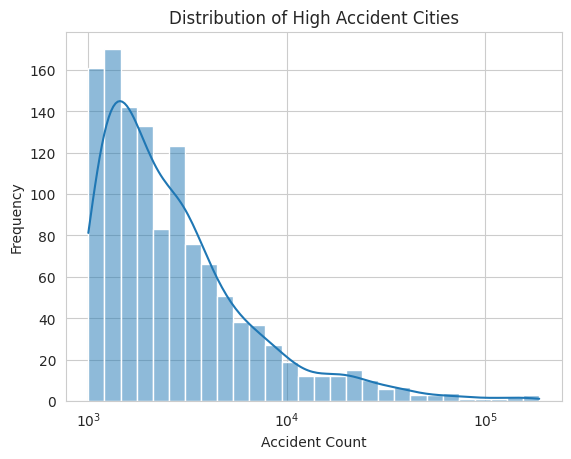

In [35]:
sns.histplot(high_accident_cities['count'], kde=True, log_scale=True)

plt.title("Distribution of High Accident Cities")
plt.xlabel("Accident Count")
plt.ylabel("Frequency")

plt.show()



Among cities with more than 1000 recorded accidents, most cities still fall closer to the lower accident range, 
while only a few cities report extremely high accident counts. This suggests that accident occurrences are 
heavily concentrated in a small number of major cities.

#### Distribution of Accident Counts in High-Accident Cities (<1000 accidents)

<Axes: ylabel='Count'>

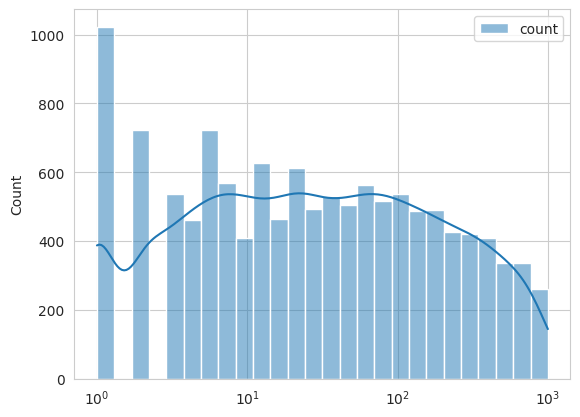

In [36]:
sns.histplot(low_accident_cities,kde=True,log_scale=True)



Most cities report a very small number of accidents, with many having fewer than 10 cases. Only a small number of cities approach higher accident counts, indicating that high-accident areas are relatively rare.

Number of cities with only one recorded accident:

In [37]:
(accidents_per_city['count'] == 1).sum()


np.int64(1023)

#### Top Cities Accident Distribution within top States

In [38]:
#relationship between top cities and states
city_state = df.groupby(['City','State']).size().reset_index(name='Accident_Count')
city_state

,City,State,Accident_Count
0,Aaronsburg,PA,21
1,Abbeville,AL,37
2,Abbeville,LA,2
3,Abbeville,MS,1
4,Abbeville,SC,564
...,...,...,...
20332,Zortman,MT,12
20333,Zumbro Falls,MN,74
20334,Zumbrota,MN,538
20335,Zuni,VA,68


In [39]:
top_cities = df['City'].value_counts().head(10)
top_state = df['State'].value_counts().head(10)
match_top = city_state[
    (city_state['City'].isin(top_cities.index)) &
    (city_state['State'].isin(top_state.index))
]

match_top





,City,State,Accident_Count
816,Austin,MN,453
818,Austin,PA,27
819,Austin,TX,96604
3125,Charlotte,NC,138345
4336,Dallas,NC,93
4337,Dallas,OR,416
4338,Dallas,PA,10
4339,Dallas,TX,130303
8479,Houston,MN,151
8483,Houston,PA,22


In [40]:
#Sum of top cities
city_list = match_top.groupby('State')['City'].apply(lambda x: ', '.join(sorted(set(x)))).reset_index(name='Cities')


state_sum = match_top.groupby('State')['Accident_Count'].sum().reset_index(name='Total_Accidents')


final_table = city_list.merge(state_sum, on='State')

final_table


,State,Cities,Total_Accidents
0,CA,"Los Angeles, Miami",156502
1,FL,"Miami, Orlando",296491
2,MN,"Austin, Houston, Miami",609
3,NC,"Charlotte, Dallas, Nashville, Raleigh",224670
4,NY,Miami,28
5,OR,"Dallas, Miami",421
6,PA,"Austin, Dallas, Houston",59
7,TX,"Austin, Dallas, Houston",396335


In [41]:
#Percentage Contribution of Cities to State Accident Totals
merged = final_table.merge(top_accident_per_state, on='State', how='left')


merged.rename(columns={'Accident_Count': 'State_Total'}, inplace=True)


merged['Percent_Contribution'] = (merged['Total_Accidents'] / merged['State_Total']) * 100


merged['Percent_Contribution'] = merged['Percent_Contribution'].round(2).astype(str) + '%'

merged


,State,Cities,Total_Accidents,State_Total,Percent_Contribution
0,CA,"Los Angeles, Miami",156502,1741433,8.99%
1,FL,"Miami, Orlando",296491,880192,33.68%
2,MN,"Austin, Houston, Miami",609,192084,0.32%
3,NC,"Charlotte, Dallas, Nashville, Raleigh",224670,338199,66.43%
4,NY,Miami,28,347960,0.01%
5,OR,"Dallas, Miami",421,179660,0.23%
6,PA,"Austin, Dallas, Houston",59,296620,0.02%
7,TX,"Austin, Dallas, Houston",396335,582837,68.0%


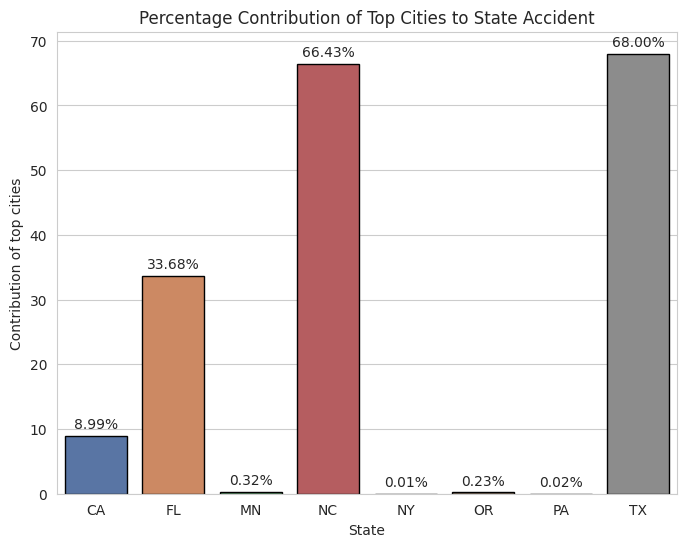

In [42]:
plt.figure(figsize=(8,6))
merged['Percent_Contribution_numeric'] = merged['Percent_Contribution'].str.rstrip('%').astype(float)
ax=sns.barplot(data=merged, x='State', y='Percent_Contribution_numeric',hue='State',palette='deep',edgecolor='black')
for container in ax.containers: ax.bar_label(container, fmt='%.2f%%', label_type='edge', padding=3)
plt.ylabel("Contribution of top cities")
plt.title('Percentage Contribution of Top Cities to State Accident')
plt.show()


1. “Some states, like Texas and North Carolina, have a high percentage of accidents coming from a few major cities, meaning their state totals are strongly city-driven.”

2. “In states like California and Florida, the listed cities contribute much less, showing that accidents are more spread across many cities.”

3. “A few states show almost no contribution from the listed cities, which means their accident totals come from other cities not shown in this table.”

4. “Overall, top accident states do not follow one pattern — some are dominated by major cities, while others have a wider distribution of accident locations.”

#### accident trend using start lat and start lng

In [43]:
# accident trend using start lat and start lng
import folium
from folium.plugins import HeatMap

In [44]:
# Count missing values in each column
missing_values = df[['Start_Lat', 'Start_Lng']].isnull().sum()
print(missing_values)


Start_Lat    0
Start_Lng    0
dtype: int64


In [45]:
#  sample max 100,000 rows for performance
sample_size = min(len(df), 100000)
df_sample = df.sample(n=sample_size, random_state=42)


In [46]:
heat_data = df_sample[['Start_Lat', 'Start_Lng']].values.tolist()


In [47]:

lat_center = df['Start_Lat'].mean()
lng_center = df['Start_Lng'].mean()

m = folium.Map(location=[lat_center, lng_center], zoom_start=6)


In [48]:
HeatMap(heat_data, radius=8, blur=12, max_zoom=1).add_to(m)
m.save('accident_heatmap.html')



In [49]:
from IPython.display import IFrame

# Display the saved HTML inline
IFrame('accident_heatmap.html', width=800, height=600)



The heatmap shows the geographic concentration of accidents across the United States.  
Major metropolitan areas have higher accident density compared to rural areas.

### Time-Based Accident Analysis

In [50]:
df['Start_Time']

0          2016-02-08 05:46:00
1          2016-02-08 06:07:59
2          2016-02-08 06:49:27
3          2016-02-08 07:23:34
4          2016-02-08 07:39:07
                  ...         
7728389    2019-08-23 18:03:25
7728390    2019-08-23 19:11:30
7728391    2019-08-23 19:00:21
7728392    2019-08-23 19:00:21
7728393    2019-08-23 18:52:06
Name: Start_Time, Length: 7728394, dtype: object

In [51]:
# Convert Start_Time to datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')


In [52]:
missing_start_time = df['Start_Time'].isna().sum()
total_rows = len(df)
print(f"Missing Start_Time: {missing_start_time} out of {total_rows} rows")


Missing Start_Time: 743166 out of 7728394 rows


Approximately 9.6% of records had missing or invalid Start_Time.
When extracting year, month, or hour for analysis, these rows were automatically ignored by pandas.
Therefore, all charts and statistics are based on the remaining valid records.
Some years (e.g., 2023) are incomplete and are excluded from certain analyses to avoid misleading trends.

In [53]:
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Weekday'] = df['Start_Time'].dt.day_name()
df['Hour'] = df['Start_Time'].dt.hour


#### Yearly analysis:

In [54]:
#the trend of accidents over the years
accident_over_years = df.groupby('Year').size().reset_index(name='Accident_Count')

accident_over_years

,Year,Accident_Count
0,2016.0,410821
1,2017.0,717290
2,2018.0,893426
3,2019.0,954302
4,2020.0,1161598
5,2021.0,1412433
6,2022.0,1268806
7,2023.0,166552


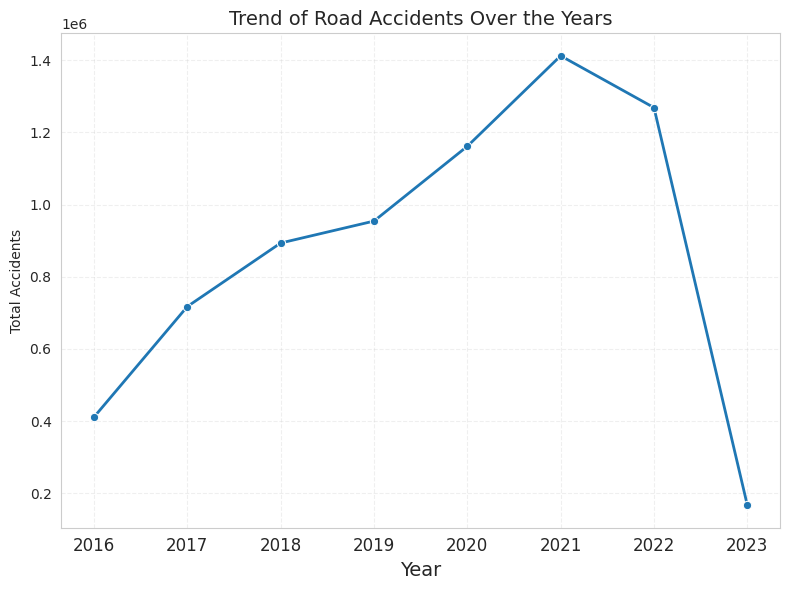

In [55]:
plt.figure(figsize=(8,6))

sns.lineplot(
    data=accident_over_years,
    x='Year',
    y='Accident_Count',
    marker='o',
    linewidth=2
)


plt.title('Trend of Road Accidents Over the Years', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Accidents', fontsize=10)


plt.grid(True, linestyle='--', alpha=0.3)


plt.xticks(accident_over_years['Year'],  fontsize=12)
plt.yticks(fontsize=10)


plt.tight_layout()

plt.show()


From 2016 to 2021, road accidents show a steady upward trend, indicating that accidents were increasing every year and reached their peak in 2021. After 2021, accidents started to decline, with a noticeable drop in 2022 and a sudden sharp fall in 2023, which needs further analysis to know the real reason.

#### why in 2023 the rate of accident suddenly deccreased so much?

In [56]:
months = df[df['Year'] == 2023]['Start_Time'].dt.month_name()
print(months.unique())



['March' 'February' 'January']


Accident counts appear lower in 2023 because the dataset does not include the full year of data (3 months only)

#### Monthly analysis:

In [57]:
monthly_accident=df.groupby(['Year','Month']).size().reset_index(name='Count')
monthly_accident

,Year,Month,Count
0,2016.0,1.0,7
1,2016.0,2.0,985
2,2016.0,3.0,6330
3,2016.0,4.0,18088
4,2016.0,5.0,17610
...,...,...,...
82,2022.0,11.0,88386
83,2022.0,12.0,127722
84,2023.0,1.0,108815
85,2023.0,2.0,37428


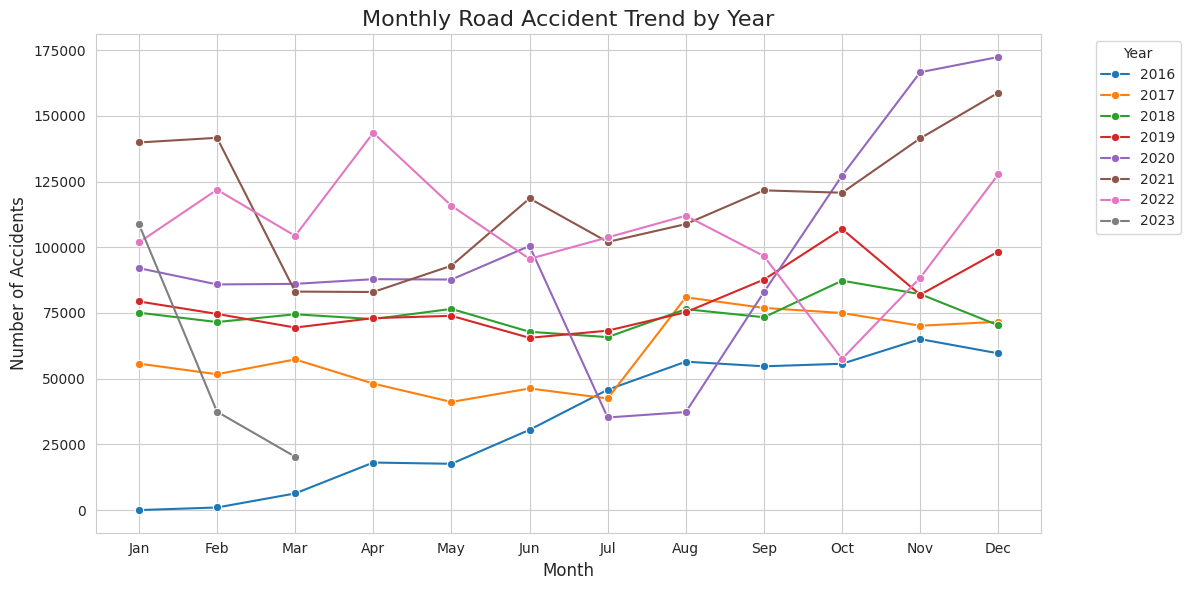

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Year and Month to int just in case
monthly_accident['Year'] = monthly_accident['Year'].astype(int)
monthly_accident['Month'] = monthly_accident['Month'].astype(int)

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_accident,
    x='Month',
    y='Count',
    hue='Year',
    marker='o',
    palette='tab10'
)
plt.title('Monthly Road Accident Trend by Year', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(ticks=range(1,13), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


The analysis reveals a consistent seasonal spike in accidents during Q4 (October–December) across multiple years, indicating predictable high-risk periods driven by increased travel and traffic congestion.

A clear upward trend is observed from 2016 to 2022, suggesting rising traffic exposure and growing road safety challenges. Additionally, recent years demonstrate higher monthly volatility, indicating evolving mobility patterns.

Note: 2023 data includes only the first three months; therefore, full-year trend comparisons are limited.

In [59]:
# removing 2023 as the full data is not available  
monthly_accident_complete = monthly_accident[monthly_accident['Year'] != 2023]


#### Seasonal Accident Risk Analysis

In [60]:
import calendar

# Create a new column 'Month_Name' using the numeric 'Month' column
monthly_accident_complete['Month_Name'] = monthly_accident_complete['Month'].apply(lambda x: calendar.month_name[x])


/tmp/ipykernel_55/869417366.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [61]:
monthly_total = (
    monthly_accident_complete
    .groupby('Month_Name')['Count']
    .sum()
    .reindex(list(calendar.month_name[1:]))  
    .sort_values(ascending=False)
)


In [62]:
highest_month = monthly_total.idxmax()
lowest_month = monthly_total.idxmin()

highest_value = monthly_total.max()
lowest_value = monthly_total.min()


In [63]:
percentage_increase = ((highest_value - lowest_value) / lowest_value) * 100
print("Highest Risk Month:", highest_month)
print("Lowest Risk Month:", lowest_month)
print(f"Seasonal variation: {percentage_increase:.2f}% increase from lowest to highest month")


Highest Risk Month: December
Lowest Risk Month: July
Seasonal variation: 63.79% increase from lowest to highest month


Accident counts vary significantly by season, with December showing the highest risk and July the lowest. The difference represents a 63.79% increase, highlighting strong seasonal variation in accident frequency.

### Hourly accident pattern:

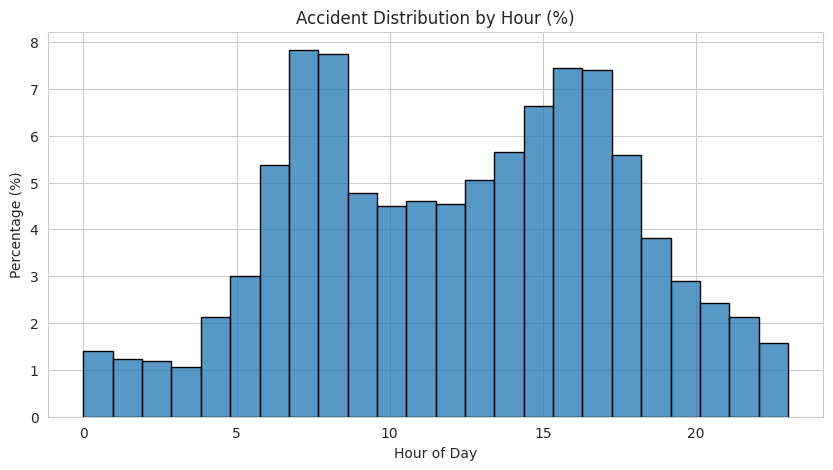

In [64]:
plt.figure(figsize=(10,5))
sns.set_style(style='whitegrid')

sns.histplot(
    df['Hour'],
    bins=24,
    stat='percent',edgecolor='black'
)

plt.title("Accident Distribution by Hour (%)")
plt.xlabel("Hour of Day")
plt.ylabel("Percentage (%)")

plt.show()


1.Morning Rush (6:00 AM – 9:00 AM): The highest frequency occurs during this window, peaking at 7:00 AM. This is likely driven by high traffic density and time-pressure during the morning commute.

2.Evening Rush (2:00 PM – 6:00 PM): A secondary sustained peak occurs in the late afternoon. This correlates with the "school run" and the transition of the workforce heading home.

3.The Mid-Day Plateau (10:00 AM – 1:00 PM): Rates stabilize and dip between the two peaks. While roads remain active, the lack of "rush hour" urgency results in a lower percentage of incidents.

4.Late Night Minimum (1:00 AM – 4:00 AM): Accidents reach their lowest point during these hours, directly corresponding with minimum vehicle volume.

### Weekday analysis:

<Axes: xlabel='Weekday', ylabel='Count'>

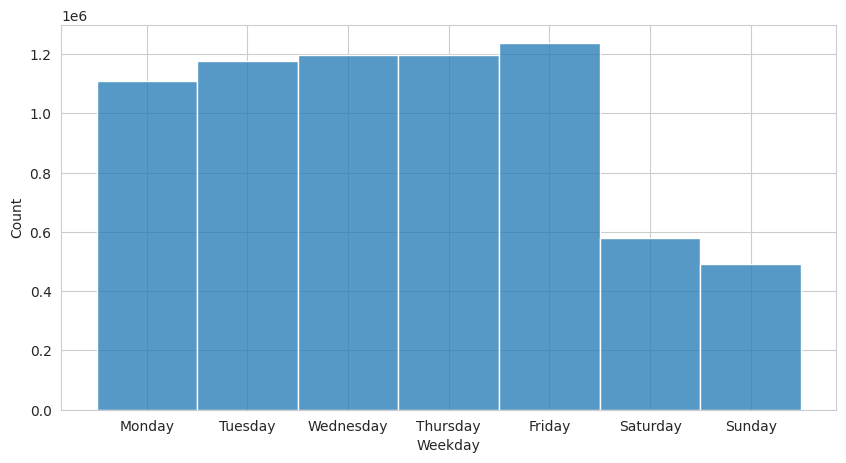

In [65]:
plt.figure(figsize=(10,5))
sns.set_style(style='whitegrid')
sns.histplot(data=df,x='Weekday', bins=7)

Accidents peak on Fridays, with Tuesday–Thursday also showing high counts, while weekends (Saturday and Sunday) record significantly fewer accidents. This suggests weekday traffic patterns drive higher risk compared to weekends.

#### Weekend Hourly Accident Trends

In [66]:
weekends = ['Saturday', 'Sunday']

df_weekend = df[df['Weekday'].isin(weekends)]


In [67]:
weekends = df[df['Start_Time'].dt.dayofweek.isin([5, 6])]


In [68]:
weekends['Weekday'].unique()


array(['Saturday', 'Sunday'], dtype=object)

<Axes: xlabel='Hour', ylabel='Percent'>

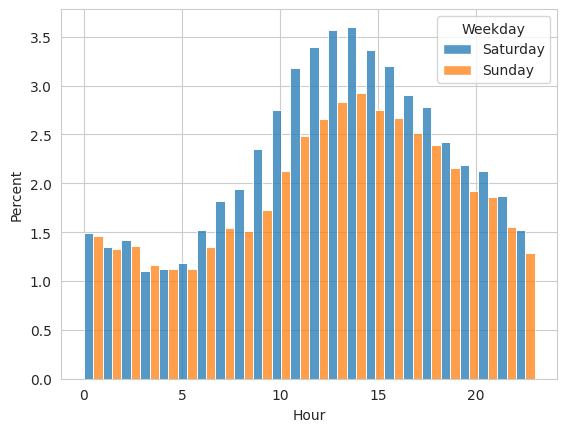

In [69]:
sns.histplot(data=weekends,x='Hour',hue='Weekday', bins=24,
    stat='percent',
    multiple='dodge')

1.Activity is lowest during late night and early morning (0–5 AM) on both days, indicating minimal movement or engagement during sleeping hours.

2.A steady rise starts after 6–7 AM, showing the beginning of daily activity on weekends.

3.Peak activity occurs between 12 PM and 3 PM for both Saturday and Sunday.

4.Saturday consistently shows higher percentages than Sunday, especially during peak hours, suggesting Saturdays are more active overall.

5.Sunday activity is slightly delayed and lower, which may reflect rest, family time, or preparation for the upcoming workweek.

6.After 6 PM, activity gradually declines on both days, returning to low levels by late night.

### the impact of weather  on severity

In [70]:
df[['Severity','Weather_Condition','Visibility(mi)','Precipitation(in)']].isnull().sum()


Severity                  0
Weather_Condition         0
Visibility(mi)       177098
Precipitation(in)         0
dtype: int64

In [71]:
df.shape

(7728394, 48)

####  Impact of Visibility on Accident Severity

In [72]:
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())

In [73]:
df['Visibility(mi)'].isnull().sum()

np.int64(0)

In [74]:
desc=df['Visibility(mi)'].describe()
desc_rounded = desc.round(0)

print(desc_rounded)

count    7728394.0
mean           9.0
std            3.0
min            0.0
25%           10.0
50%           10.0
75%           10.0
max          140.0
Name: Visibility(mi), dtype: float64


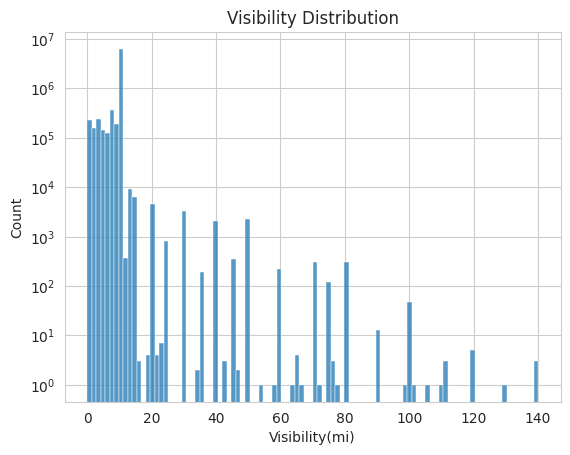

In [75]:
sns.histplot(data=df,x='Visibility(mi)',bins=100)
plt.yscale('log')
plt.title("Visibility Distribution")

plt.show()


Create visibility category

In [76]:
bins = [-1, 0.25, 1, 5, 140]
labels = ['Extreme', 'Low', 'Moderate', 'Clear']
df['Visibility_Category'] = pd.cut(df['Visibility(mi)'], bins=bins, labels=labels)



In [77]:
df['Visibility_Category']

0          Clear
1          Clear
2          Clear
3          Clear
4          Clear
           ...  
7728389    Clear
7728390    Clear
7728391    Clear
7728392    Clear
7728393    Clear
Name: Visibility_Category, Length: 7728394, dtype: category
Categories (4, object): ['Extreme' < 'Low' < 'Moderate' < 'Clear']

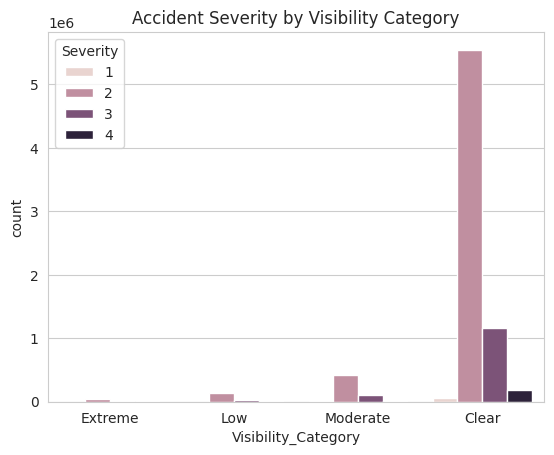

In [78]:
sns.countplot(data=df, x='Visibility_Category', hue='Severity')
plt.title("Accident Severity by Visibility Category")

plt.show()

/tmp/ipykernel_55/2041144092.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



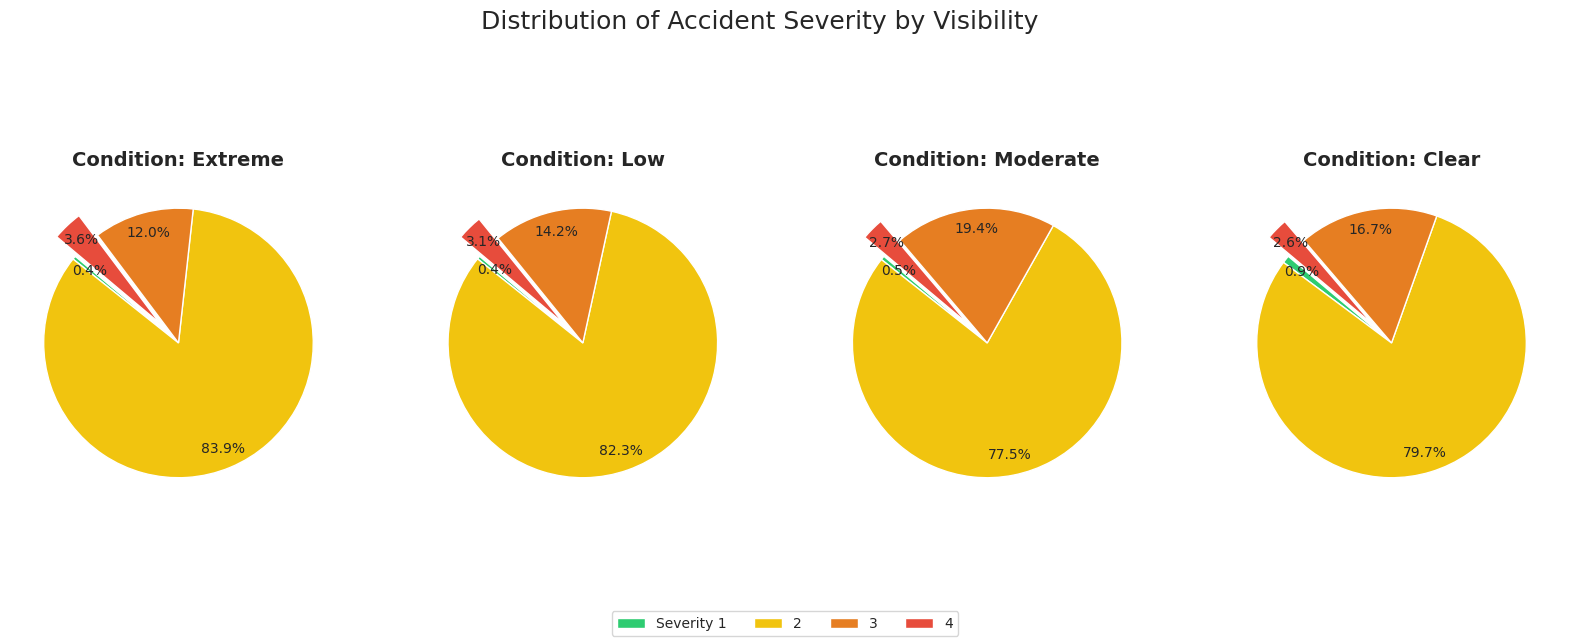

In [79]:



pie_data = df.groupby(['Visibility_Category', 'Severity']).size().unstack(fill_value=0)


categories = pie_data.index
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'] 
fig, axes = plt.subplots(1, 4, figsize=(20, 6))


for i, cat in enumerate(categories):
    axes[i].pie(pie_data.loc[cat], 
                autopct='%1.1f%%', 
                startangle=140, 
                colors=colors,
                pctdistance=0.85,
                explode=[0, 0, 0, 0.2])
    axes[i].set_title(f'Condition: {cat}', fontsize=14, fontweight='bold')

plt.figlegend(labels=['Severity 1', '2', '3', '4'], loc='lower center', ncol=4)
plt.suptitle('Distribution of Accident Severity by Visibility', fontsize=18, y=1.05)
plt.show()

Accident severity distribution remains similar across visibility conditions, with Severity 2 dominating. However, the proportion of the most severe accidents slightly increases as visibility worsens, indicating that poor visibility contributes to more dangerous crashes.

####  Impact of Weather Conditions on Accidents

In [80]:
weather_effect=df.groupby('Weather_Condition')['Severity'].mean().sort_values(ascending=False).reset_index(name='Average Severity')
WE=weather_effect.head(10)

/tmp/ipykernel_55/1328688836.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




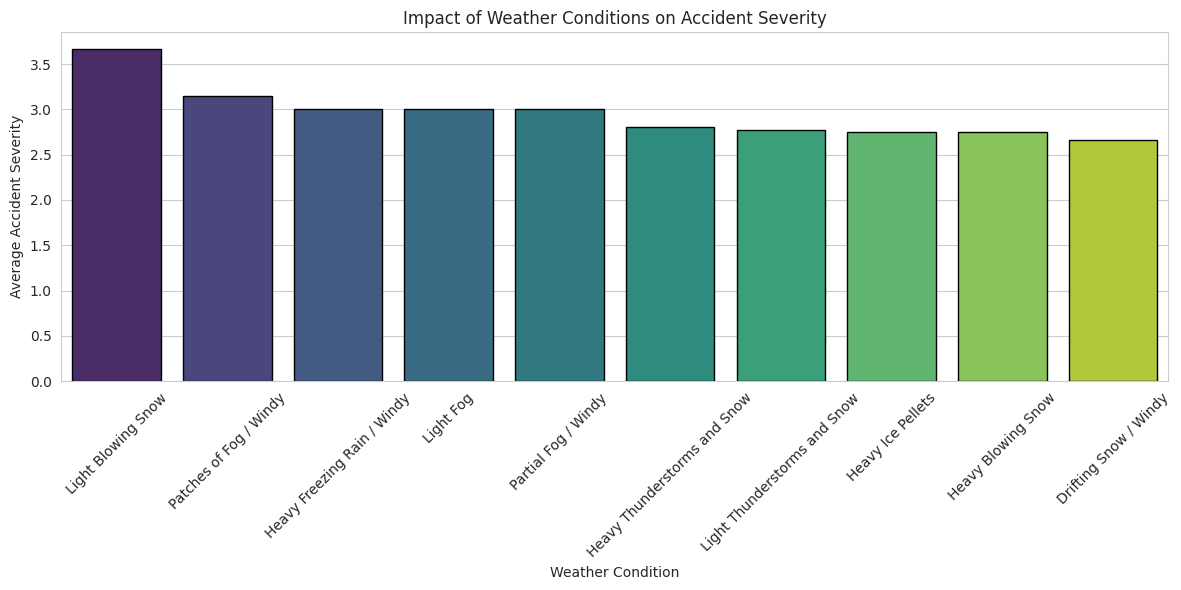

In [81]:
plt.figure(figsize=(12,6))
sns.barplot(data=WE,x='Weather_Condition',y='Average Severity',palette='viridis',edgecolor='black')
plt.xticks(rotation=45)
plt.title('Impact of Weather Conditions on Accident Severity')
plt.xlabel('Weather Condition')
plt.ylabel('Average Accident Severity')

plt.tight_layout()
plt.show()

In [82]:
weather_counts = df['Weather_Condition'].value_counts().reset_index()
weather_counts.head(10) 

,Weather_Condition,count
0,Fair,2734261
1,Mostly Cloudy,1016195
2,Cloudy,817082
3,Clear,808743
4,Partly Cloudy,698972
5,Overcast,382866
6,Light Rain,352957
7,Scattered Clouds,204829
8,Light Snow,128680
9,Fog,99238


In [83]:
Most accidents occur during normal weather conditions such as fair and cloudy weather, primarily due to higher traffic volume. However, adverse weather conditions like rain, snow, and fog still contribute significantly to accident occurrences due to reduced visibility and road traction.

SyntaxError: invalid syntax (1464265838.py, line 1)

## Key Insights

- A small number of cities account for a large proportion of accidents.
- Major metropolitan areas show higher accident density.
- Accidents peak during morning and evening rush hours.
- Lower visibility conditions tend to be associated with higher accident severity.
- Weather conditions such as rain and fog increase accident risk.

## Conclusion
The analysis provides valuable insights into the patterns and factors influencing traffic accidents across the United States. By uncovering spatial, temporal, and environmental trends, this study lays the groundwork for deeper investigation and practical applications. These findings not only enhance our understanding of accident dynamics but also highlight opportunities for predictive modeling and targeted interventions aimed at improving road safety and reducing accident severity.